In [17]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

from pathlib import Path
import sys
sys.path.append('../../')
from sklearn.preprocessing import QuantileTransformer
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score,calinski_harabasz_score, davies_bouldin_score

In [19]:
sensory_feature_names = ["initial_L_0","initial_L_1","initial_L_2","initial_m_0","initial_m_1","initial_m_2","cosine_avoidance_0","cosine_avoidance_1","cosine_avoidance_2", "distance_to_wall"]
motor_feature_names = ["T_burst","cum_delta_theta","delta_L_0","delta_L_1","delta_L_2","delta_m_0","delta_m_1","delta_m_2","reaction_time_0","reaction_time_1","reaction_time_2", "delta_v"]

fish_ages = [4,6,8]
evalutation_metrics_names = ["avg_max_prob", "bic", "aic", "silhouette", "calinski_harabasz_score", "davies_bouldin_score"]


In [20]:
# load feature dfs

with open('agewise_burst_features_dfs.pkl', 'rb') as f:
    agewise_burst_features_dfs = pickle.load(f)

# Find optimal number of sensory and motor clusters

In [6]:
def fit_gmms_and_evaluate_metrics(df : pd.DataFrame, max_components = 5, n_init = 10, random_state=42, scaling = True):
    """
    Find the optimal number of components for a GMM by fitting it for different numbers of components and evaluating the performance.    
    Parameters:
    -----------
    df : pd.Dataframe (n_samples, n_features)
        The input data to fit the GMM on
    max_components : int
        max number of components to consider
    n_init : int
        number of initializations
    random_state : int, default=42
        Random state for reproducibility
    scaling : bool
        If true data will be transformed using QuantileTransformer to have a normal distribution

    Returns:
    -------- 
    evaluation_metrics
   """

    # Scale the data
    if scaling:
        scaler = QuantileTransformer(output_distribution='normal')    
        feature_matrix = scaler.fit_transform(df)
    else:
        feature_matrix = df.values
    
    # Fit a GMM for each value of n_components and get metrics
    n_components = np.arange(1,max_components+1)
    gmms_list = []

    #metrics : avg max posterior probability, BIC, AIC, silhouette score, calinski_harabasz_score, davies_bouldin_score
    evaluation_metrics = np.empty((len(n_components),6)) 

    for i,n in enumerate(n_components):
        gmm = GaussianMixture(
            n_components=n,
            covariance_type='full',
            random_state=random_state,
            n_init=n_init,
            init_params='kmeans'
        )

        gmm.fit(feature_matrix)
        labels = gmm.predict(feature_matrix)

        # metrics where lower is better
        db_score = davies_bouldin_score(feature_matrix, labels) if len(np.unique(labels)) > 1 else np.nan
        bic = gmm.bic(feature_matrix)
        aic = gmm.aic(feature_matrix)

        # metrics where higher is better
        ch_score = calinski_harabasz_score(feature_matrix, labels) if len(np.unique(labels)) > 1 else np.nan
        silhouette = silhouette_score(feature_matrix, labels) if len(np.unique(labels)) > 1 else np.nan
        avg_max_prob = np.mean(np.max(gmm.predict_proba(feature_matrix), axis=1))

        evaluation_metrics[i,:] = [avg_max_prob, bic, aic, silhouette, ch_score, db_score]
        gmms_list.append(gmm)
        print(f"Fitted GMM with {n} components at {pd.Timestamp.now()}")
    return evaluation_metrics, gmms_list


In [7]:
# Evaluate GMMs for each age for sensory and motor features separetely

results_path = Path('../../Results/agewise_burst_glide_feature_clustering.pkl')

if results_path.is_file():
    with open(results_path, 'rb') as f:
        results = pickle.load(f)
        agewise_evaluation_metrics_sensory = results['agewise_evaluation_metrics_sensory']
        agewise_evaluation_metrics_motor = results['agewise_evaluation_metrics_motor']
        agewise_gmms_sensory = results['agewise_gmms_sensory']
        agewise_gmms_motor = results['agewise_gmms_motor']
        n_components = results['n_components']
        evaluation_metrics_names = results['metric_names']
else:
    agewise_evaluation_metrics_sensory = []
    agewise_evaluation_metrics_motor = []
    agewise_gmms_sensory = []
    agewise_gmms_motor = []

    max_components = 15
    n_init = 1000

    for i,age in enumerate(fish_ages):
        print(f"Starting GMM evaluation for age {age} weeks at {pd.Timestamp.now()}")
        # sensory features
        df = agewise_burst_features_dfs[f'{age}wpf'][sensory_feature_names]
        sensory_metrics, sensory_gmms = fit_gmms_and_evaluate_metrics(df, max_components, n_init, scaling = True)
        agewise_evaluation_metrics_sensory.append(sensory_metrics)
        agewise_gmms_sensory.append(sensory_gmms)

        # motor features
        df = agewise_burst_features_dfs[f'{age}wpf'][motor_feature_names]
        motor_metrics, motor_gmms = fit_gmms_and_evaluate_metrics(df, max_components, n_init, scaling = True)
        agewise_evaluation_metrics_motor.append(motor_metrics)
        agewise_gmms_motor.append(motor_gmms)

        print(f"Completed GMM evaluation for age {age} weeks at {pd.Timestamp.now()}")
        print("------------------------------------------------------------")

    results_dict ={
    "n_components": np.arange(1,max_components+1),
    "metric_names": evalutation_metrics_names,
    "agewise_evaluation_metrics_sensory": agewise_evaluation_metrics_sensory,
    "agewise_evaluation_metrics_motor": agewise_evaluation_metrics_motor,
    "agewise_gmms_sensory": agewise_gmms_sensory,
    "agewise_gmms_motor": agewise_gmms_motor
    }

    # write to file
    with open(results_path, 'wb') as f:
        pickle.dump(results_dict, f)

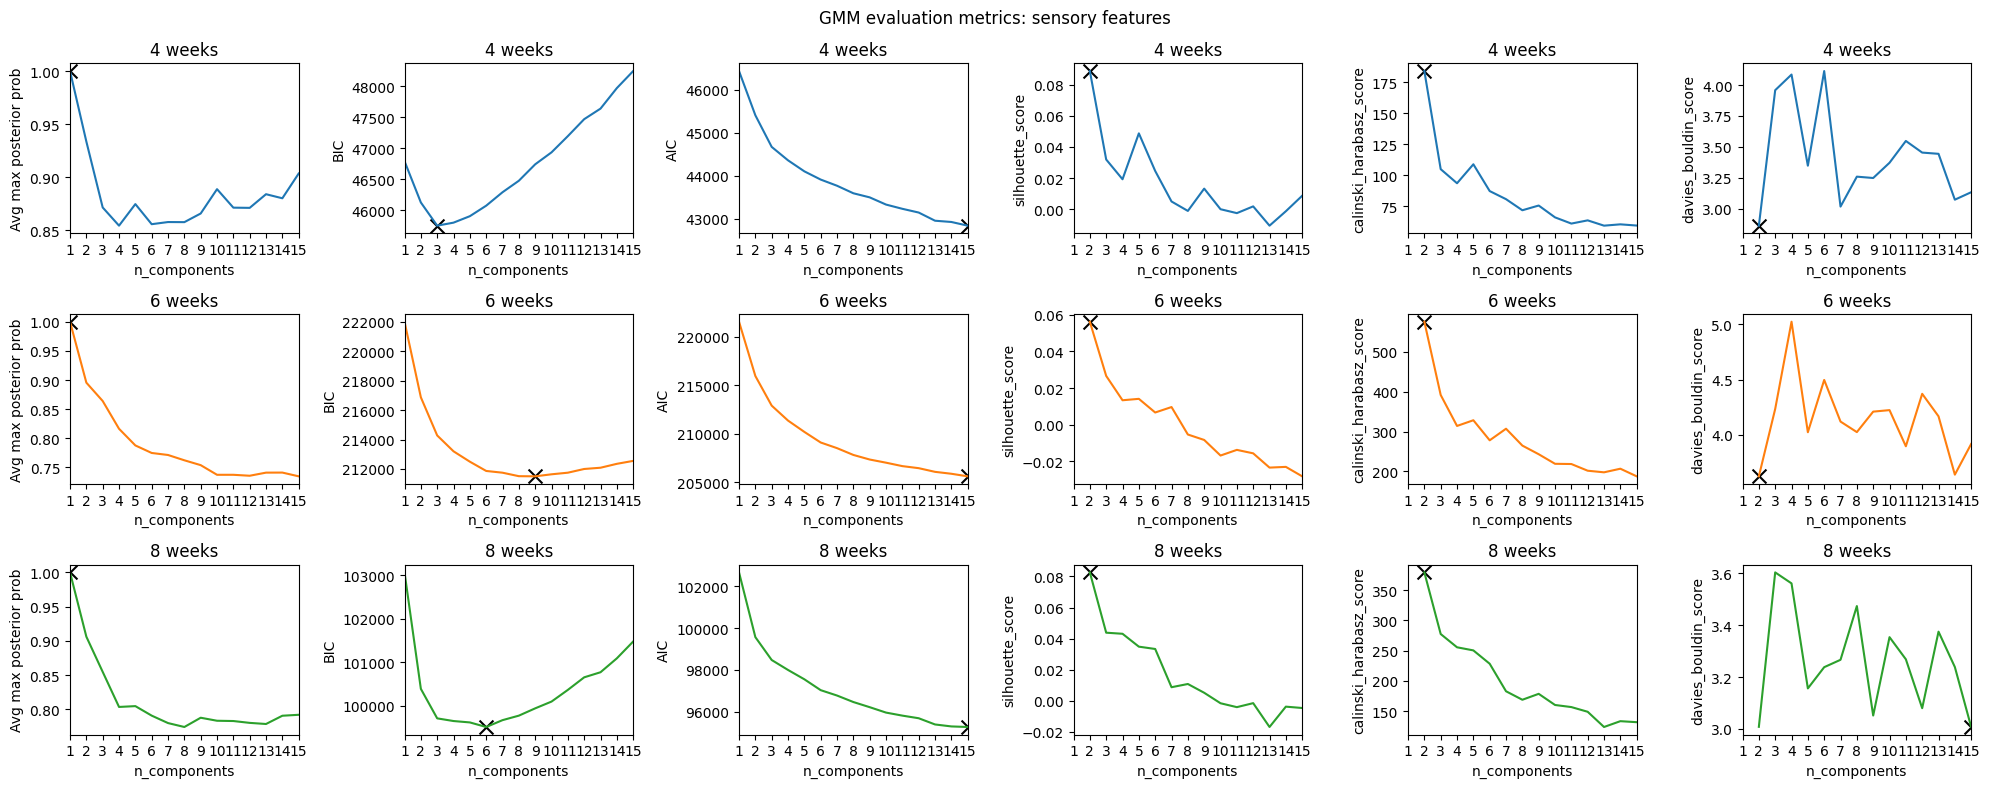

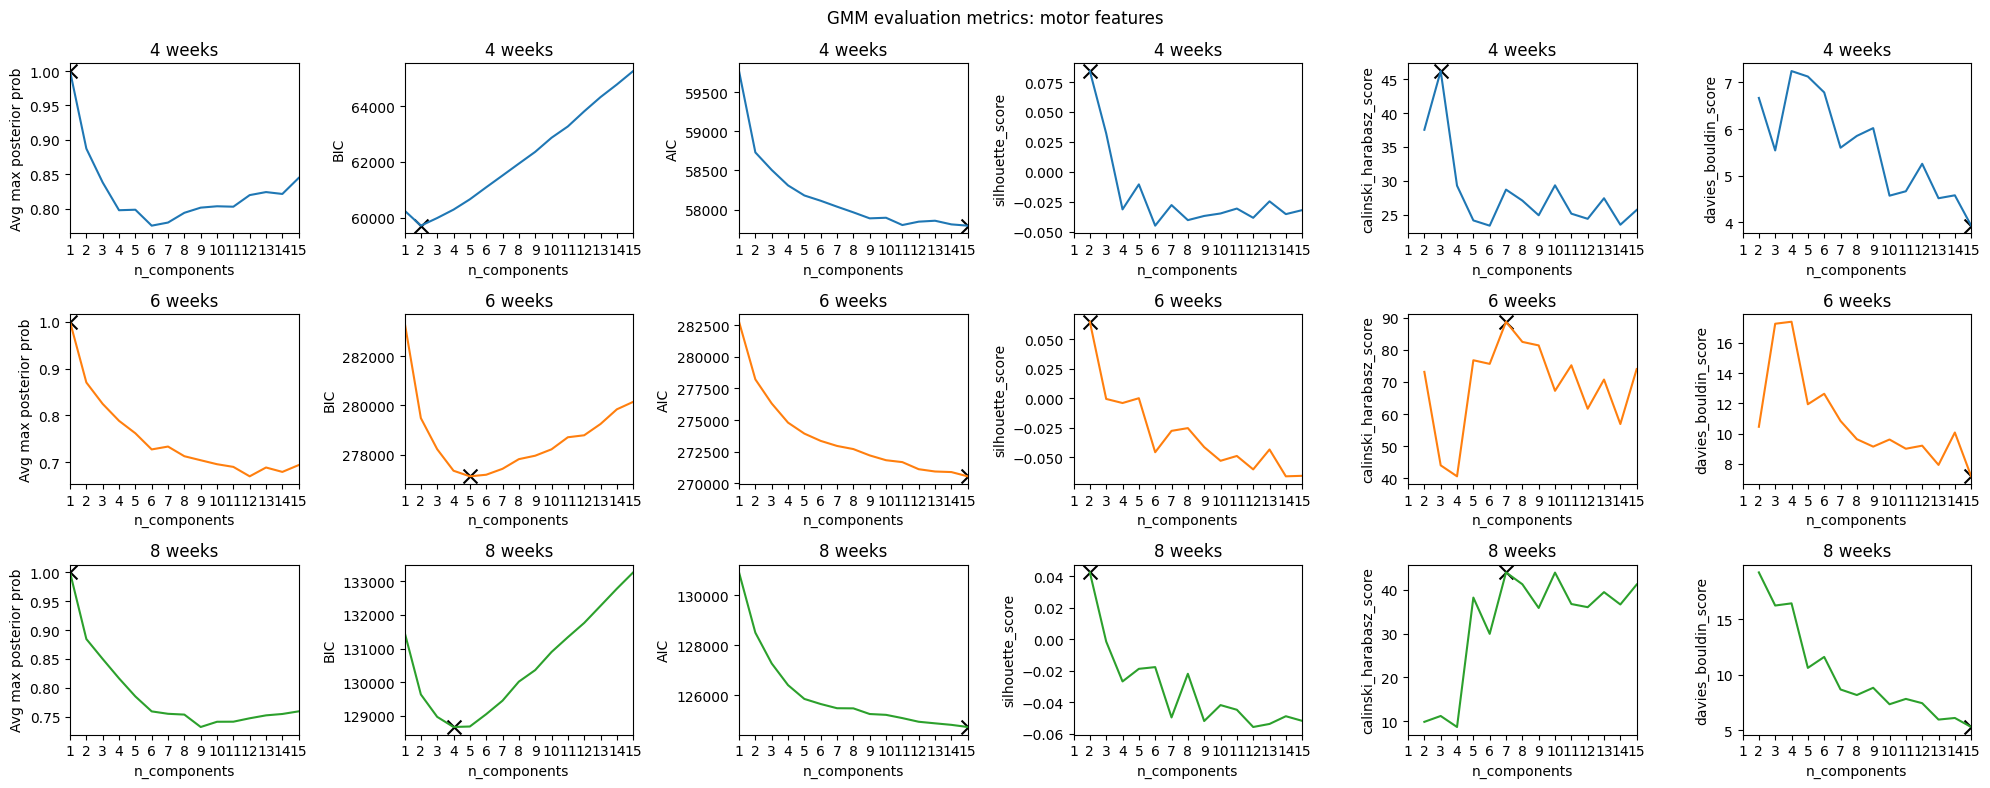

In [9]:
# plotting
fig1,ax1 = plt.subplots(3,6,figsize=(20,8))
fig2,ax2 = plt.subplots(3,6,figsize=(20,8))
plot_colors= ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
ylabels = ["Avg max posterior prob", "BIC", "AIC", "silhouette_score", "calinski_harabasz_score", "davies_bouldin_score"]

for i, age in enumerate(fish_ages):
    for j in range(6):
        ax1[i,j].plot(n_components,agewise_evaluation_metrics_sensory[i][:,j],color=plot_colors[i])
        ax2[i,j].plot(n_components,agewise_evaluation_metrics_motor[i][:,j],color=plot_colors[i])

        if j in [1,2,5]:
            # optimium is minimum
            opt_index_s = np.nanargmin(agewise_evaluation_metrics_sensory[i][:,j])
            opt_index_m = np.nanargmin(agewise_evaluation_metrics_motor[i][:,j])

        else:
            # optimium is maximum
            opt_index_s = np.nanargmax(agewise_evaluation_metrics_sensory[i][:,j])
            opt_index_m = np.nanargmax(agewise_evaluation_metrics_motor[i][:,j])

        # indicate optimal n_components
        ax1[i,j].scatter(opt_index_s+1,agewise_evaluation_metrics_sensory[i][opt_index_s,j],color='black',marker='x',s=100)
        ax2[i,j].scatter(opt_index_m+1,agewise_evaluation_metrics_motor[i][opt_index_m,j],color='black',marker='x',s=100)

        ax1[i,j].set_title(f"{age} weeks")
        ax1[i,j].set_xlabel("n_components")
        ax1[i,j].set_ylabel(ylabels[j])
        ax1[i,j].set_xticks(n_components)
        ax1[i,j].set_xlim(1, n_components[-1])

        ax2[i,j].set_title(f"{age} weeks")
        ax2[i,j].set_xlabel("n_components")
        ax2[i,j].set_ylabel(ylabels[j])
        ax2[i,j].set_xticks(n_components)
        ax2[i,j].set_xlim(1, n_components[-1])

    
fig1.suptitle("GMM evaluation metrics: sensory features")
fig1.tight_layout()

fig2.suptitle("GMM evaluation metrics: motor features")
fig2.tight_layout()


- Choosing BIC as the guiding evaluation metric, we choose the same number of motor clusters for each age ($N_M$=4).
- The chosen number of sensory clusters is $N_S=3,6,4$ for ages 4, 6, 8 weeks respectively, such that $N_S\leq \mathrm{argmin(BIC)}$ while ensuring that the resulting clusters correspond to distinct, interpretable group configurations

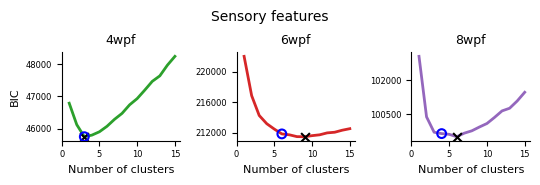

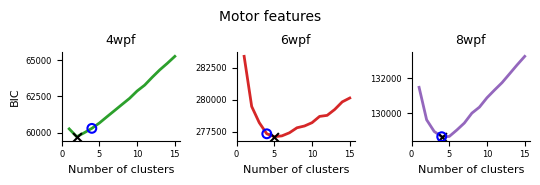

In [10]:
n_sensory_clusters = [3,6,4]
n_motor_clusters = [4,4,4]

w =  5.5
h = 2
suptitle_size = 10
title_size = 9
labelsize = 8
tick_size = 6


colors = plt.get_cmap('tab20')(fish_ages)


fig,ax = plt.subplots(1,3,figsize=(w,h))
for i, age in enumerate(fish_ages):
    bic = agewise_evaluation_metrics_sensory[i][:,1]
    ax[i].plot(range(1,len(bic)+1), bic, color=colors[i], linewidth=2)
    # find and plot minimum
    min_k = np.argmin(bic)+1
    ax[i].scatter(min_k, bic[min_k-1], marker='x', color='k', s=40,linewidth=1.5,zorder=10)
    # plot actual number of clusters
    ax[i].scatter(n_sensory_clusters[i], bic[n_sensory_clusters[i]-1], marker='o', edgecolor='blue', facecolor='none',linewidth=1.5,s=40,zorder=10)
    ax[i].set_title(f"{age}wpf", fontsize=title_size)
    ax[i].set_xlabel("Number of clusters", fontsize=labelsize)
    if i == 0:
        ax[i].set_ylabel("BIC", fontsize=labelsize)
    ax[i].tick_params(which='both', labelsize=tick_size)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xticks([0,5,10,15])
    ax[i].yaxis.set_major_locator(MaxNLocator(nbins=3))

fig.suptitle("Sensory features", fontsize=suptitle_size, y =0.9)
fig.tight_layout()

colors = plt.get_cmap('tab20')(fish_ages)
fig,ax = plt.subplots(1,3,figsize=(w,h))
for i, age in enumerate(fish_ages):
    # get the BIC values for the current age
    bic = agewise_evaluation_metrics_motor[i][:,1]
    ax[i].plot(range(1,len(bic)+1), bic, color=colors[i], linewidth=2)
    # find and plot minimum
    min_k = np.argmin(bic)+1
    ax[i].scatter(min_k, bic[min_k-1], marker='x', color='k', s=40,linewidth=1.5, zorder=10)
    # plot actual number of clusters
    ax[i].scatter(n_motor_clusters[i], bic[n_motor_clusters[i]-1], marker='o', edgecolor='blue', facecolor='none', s=40, linewidth=1.5,zorder=10)
    ax[i].set_title(f"{age}wpf", fontsize=title_size)
    ax[i].set_xlabel("Number of clusters", fontsize=labelsize)
    if i == 0:
        ax[i].set_ylabel("BIC", fontsize=labelsize)
    ax[i].tick_params(which='both', labelsize=tick_size)
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].set_xticks([0,5,10,15])
    ax[i].yaxis.set_major_locator(MaxNLocator(nbins=3))
fig.suptitle("Motor features", fontsize=suptitle_size, y=0.9)
fig.tight_layout()




------------------

# Re-run GMM fitting with larger `n_init` for chosen N_clusters

In [26]:
optimal_N_motor = [4, 4, 4]
optimal_N_sensory = [3, 6, 4]

results_path = Path('../../Results/optimal_sensory_motor_clusters.pkl')

if results_path.is_file():
    with open(results_path, 'rb') as f:
        optimal_gmm_results = pickle.load(f)
        optimal_gmms_sensory = optimal_gmm_results['optimal_gmms_sensory']
        optimal_gmms_motor = optimal_gmm_results['optimal_gmms_motor']
        agewise_burst_features_dfs_with_labels = optimal_gmm_results['feature_dfs_with_labels']
else:
    agewise_burst_features_dfs_with_labels = agewise_burst_features_dfs.copy()
    optimal_gmms_sensory = []
    optimal_gmms_motor = []
    n_init = 10000
    scaler = QuantileTransformer(output_distribution='normal')

    for i, age in enumerate(fish_ages):
        # sensory features
        df = agewise_burst_features_dfs[f'{age}wpf'][sensory_feature_names]
        df = scaler.fit_transform(df)
        gmm = GaussianMixture(
            n_components=optimal_N_sensory[i],
            covariance_type='full',
            random_state=0,
            n_init=n_init,
            init_params='kmeans'
        )
        gmm.fit(df)
        optimal_gmms_sensory.append(gmm)
        agewise_burst_features_dfs_with_labels[f'{age}wpf']['sensory_cluster'] = gmm.predict(df)
        print(f"Fitted optimal GMM for sensory features at age {age} weeks at {pd.Timestamp.now()}")

        # motor features
        df = agewise_burst_features_dfs[f'{age}wpf'][motor_feature_names]
        df = scaler.fit_transform(df)
        gmm = GaussianMixture(
            n_components=optimal_N_motor[i],
            covariance_type='full',
            random_state=0,
            n_init=n_init,
            init_params='kmeans'
        )
        gmm.fit(df)
        optimal_gmms_motor.append(gmm)
        agewise_burst_features_dfs_with_labels[f'{age}wpf']['motor_cluster'] = gmm.predict(df)
        print(f"Fitted optimal GMM for motor features at age {age} weeks at {pd.Timestamp.now()}")

    optimal_gmm_results = {
    'optimal_gmms_sensory': optimal_gmms_sensory,
    'optimal_gmms_motor': optimal_gmms_motor,
    'feature_dfs_with_labels': agewise_burst_features_dfs_with_labels
    }

    with open(results_path, 'wb') as f:
        pickle.dump(optimal_gmm_results, f)
